# Etapa 3 - Controle e PID

## 1. Engenharia de Controle em Malha Fechada e Estrutura PID

### 1.1 O Princípio da Realimentação (Malha Fechada)
O controle em malha fechada baseia-se no princípio da medição da variável de saída do processo ($y(t)$) e na sua comparação contínua com um valor de referência desejado ($r(t)$), denominado *Setpoint*. O objetivo fundamental é minimizar o erro dinâmico do sistema, definido matematicamente por:

$$e(t) = r(t) - y(t)$$

A topologia de malha fechada confere ao sistema a capacidade de rejeitar distúrbios externos, mitigar os efeitos de incertezas de modelagem e estabilizar plantas dinamicamente instáveis em malha aberta.

### 1.2 Formulação Matemática das Ações do Controlador PID
O controlador PID combina três vertentes analíticas sobre o sinal de erro: o presente (Proporcional), o passado (Integral) e a tendência futura (Derivativo). A lei de controle contínua no domínio do tempo é expressa por:

$$u(t) = K_p e(t) + K_i \int_{0}^{t} e(\tau) d\tau + K_d \frac{de(t)}{dt}$$

Onde $K_p$, $K_i$ e $K_d$ representam os ganhos proporcional, integral e derivativo, respectivamente. Aplicando a Transformada de Laplace com condições iniciais nulas, obtemos a Função de Transferência do controlador no domínio da frequência complexa ($s$):

$$C(s) = \frac{U(s)}{E(s)} = K_p + \frac{K_i}{s} + K_d s = \frac{K_d s^2 + K_p s + K_i}{s}$$

#### Análise Isolada das Ações de Controle:
* **Ação Proporcional ($K_p$):** Fornece uma atuação diretamente proporcional à magnitude do erro atual. Aumentar $K_p$ eleva a velocidade de resposta do sistema (reduz o tempo de subida) e reduz o erro em regime permanente, mas penaliza a estabilidade, introduzindo oscilações e aumentando o sobressinal (*overshoot*). Ela **não** consegue zerar o erro em regime permanente para uma entrada degrau em sistemas tipo 0.
* **Ação Integral ($K_i$):** Acumula o erro ao longo do tempo. Sua principal função matemática é aumentar o tipo do sistema em uma unidade, o que garante **erro em regime permanente nulo** para entradas do tipo degrau. Contudo, a introdução de um polo na origem ($s = 0$) adiciona um atraso de fase de $-90^\circ$, deteriorando a margem de estabilidade e provocando oscilações severas se mal sintonizado.
* **Ação Derivativa ($K_d$):** Avalia a taxa de variação do erro (velocidade de alteração). Atua como um mecanismo de antecipação e amortecimento físico, introduzindo um zero no semiplano esquerdo que adiciona avanço de fase. Isso permite mitigar as oscilações causadas pelo termo integral, reduzir o *overshoot* e diminuir o tempo de acomodação.

## 2. Implementação Digital e Discretização (Foco em Embarcados)

Para implementar o algoritmo PID em hardware digital (como microcontroladores ARM Cortex-M, ESP32 ou CLPs), a equação diferencial contínua precisa ser mapeada no domínio discreto do tempo (Z) operando a uma taxa de amostragem periódica de tempo $T$.

### 2.1 Método Clássico (Algoritmo Posicional)
Aproximando a integral pela regra dos retângulos à direita e a derivada pela diferença finita regressiva de primeira ordem (Euler Retrógrado), temos:

$$\int_{0}^{t_k} e(\tau)d\tau \approx T \sum_{j=1}^{k} e[j]$$

$$\frac{de(t)}{dt} \Big|_{t = t_k} \approx \frac{e[k] - e[k-1]}{T}$$

Substituindo na equação do PID, obtemos a equação de diferenças na forma **posicional**:

$$u[k] = K_p e[k] + K_i T \sum_{j=1}^{k} e[j] + \frac{K_d}{T} \big(e[k] - e[k-1]\big)$$

**Limitação Industrial:** O algoritmo posicional exige a computação da somatória de todos os erros passados a cada ciclo, gerando riscos de estouro de memória ou saturação do integrador (*Windup Integral*), além de provocar surtos na saída se os ganhos forem alterados dinamicamente em tempo real.

### 2.2 Algoritmo de Velocidade ou Recorrente (Padrão Industrial)
Para contornar as limitações da forma posicional, calcula-se a diferença entre a lei de controle do instante atual $u[k]$ e do instante imediatamente anterior $u[k-1]$:

$$\Delta u[k] = u[k] - u[k-1]$$

Desenvolvendo matematicamente a subtração dos termos, a componente somatória da integral é eliminada, resultando na **Equação Recorrente de Velocidade**:

$$u[k] = u[k-1] + q_0 e[k] + q_1 e[k-1] + q_2 e[k-2]$$

Onde os coeficientes de filtragem digital baseados nos parâmetros contínuos são definidos por:

$$q_0 = K_p + K_i T + \frac{K_d}{T}$$

$$q_1 = -K_p - \frac{2K_d}{T}$$

$$q_2 = \frac{K_d}{T}$$

**Vantagens Práticas:**
1. **Eficiência Computacional:** Requer apenas o armazenamento do sinal de controle anterior $u[k-1]$ e dos dois erros anteriores ($e[k-1]$ e $e[k-2]$), perfeito para microcontroladores de recursos escassos.
2. **Suavidade na Troca de Parâmetros:** Mudanças nos ganhos feitas por um operador não geram transientes abruptos na saída.
3. **Proteção Nativa contra Windup:** Como a atuação é incremental, se o atuador físico atingir o limite físico de saturação, basta travar o incremento $\Delta u[k]$, cessando o acúmulo matemático imediatamente.

In [2]:
!pip install control matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.3 MB/s eta 0:00:00


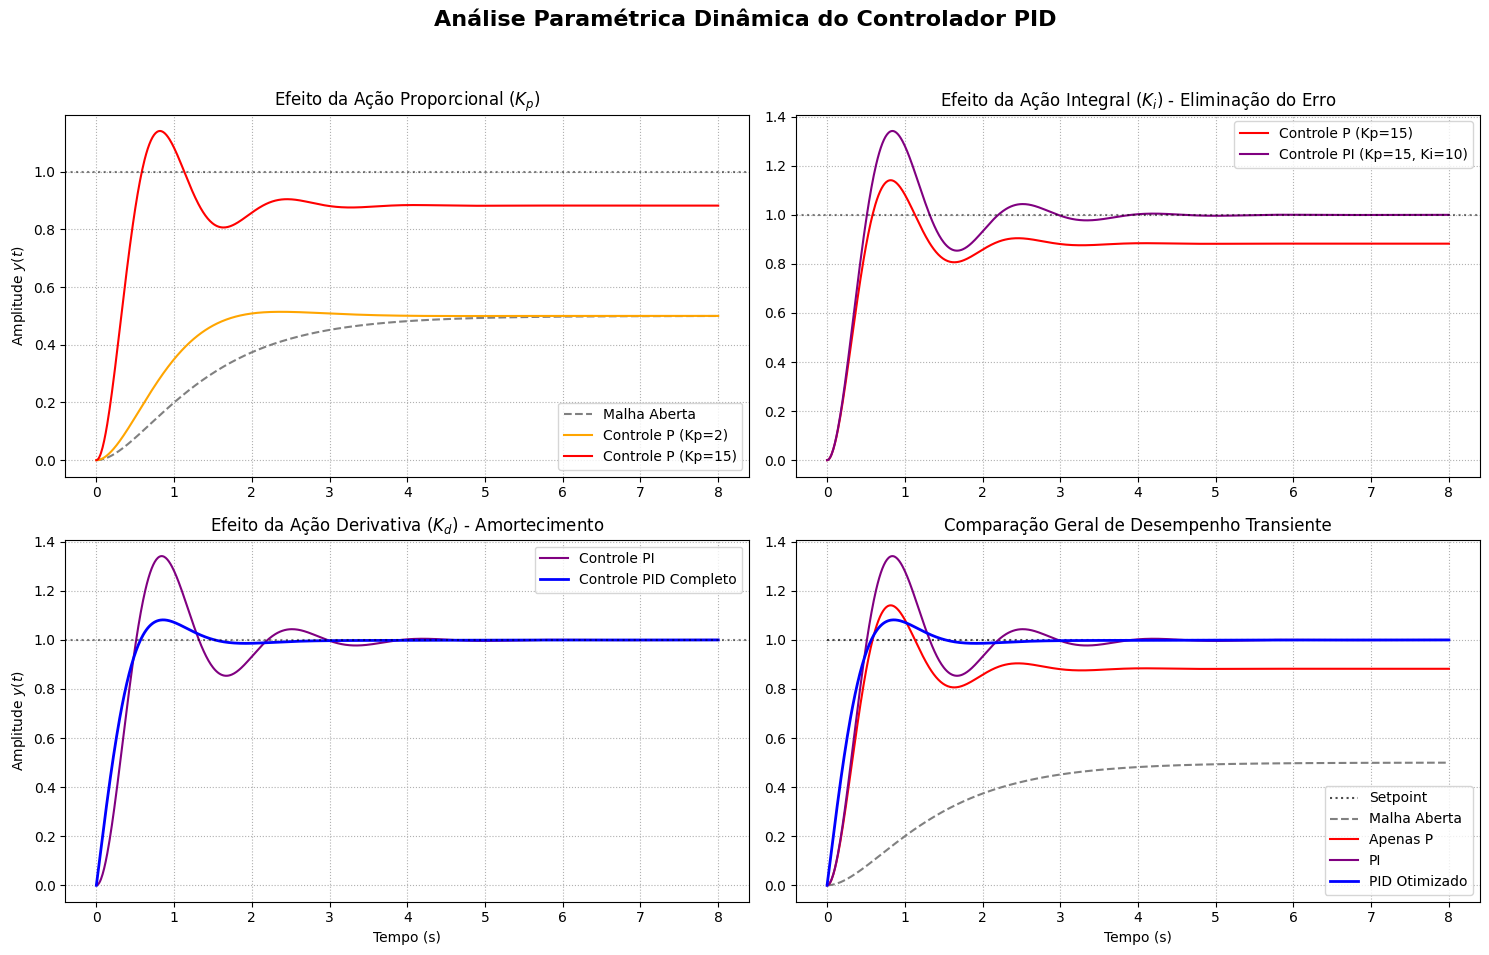


             TABELA COMPARATIVA DE DESEMPENHO DOS CONTROLADORES             
1. Malha Aberta        | TR: 2.599s | TA: 4.651s | OS: 0.00% | Erro F.: 50.03%
2. Controle P (Baixo)  | TR: 1.163s | TA: 2.884s | OS: 2.84% | Erro F.: 50.00%
3. Controle P (Alto)   | TR: 0.326s | TA: 2.651s | OS: 29.23% | Erro F.: 11.76%
4. Controle PI         | TR: 0.382s | TA: 3.501s | OS: 34.12% | Erro F.: 0.02%
5. Controle PID Completo | TR: 0.404s | TA: 1.387s | OS: 8.17% | Erro F.: 0.01%


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct


# DEFINIÇÃO DA PLANTA (Sistema de Segunda Ordem)
# G(s) = 1 / (s^2 + 3s + 2) -> Polos em s = -1 e s = -2 (Estável)
num = [1]
den = [1, 3, 2]
G = ct.tf(num, den)

tempo = np.linspace(0, 8, 800)

# CENÁRIOS DE SIMULAÇÃO PARA ANÁLISE DOS EFEITOS DO PID

# Cenário A: Efeito do Ganho Proporcional (Variação de Kp)
T_p_baixo = ct.feedback(ct.tf([2], [1]) * G, 1)
T_p_alto  = ct.feedback(ct.tf([15], [1]) * G, 1)

# Cenário B: Efeito da Ação Integral (Adição de Ki)
T_pi = ct.feedback(ct.tf([15, 10], [1, 0]) * G, 1)

# Cenário C: Sistema com Controle PID Completo
Kp, Ki, Kd = 15, 10, 2.5
C_pid = ct.tf([Kd, Kp, Ki], [1, 0])
T_pid = ct.feedback(C_pid * G, 1)

# EXECUÇÃO DAS RESPOSTAS AO DEGRAU
_, y_ma       = ct.step_response(G, T=tempo)
_, y_p_baixo  = ct.step_response(T_p_baixo, T=tempo)
_, y_p_alto   = ct.step_response(T_p_alto, T=tempo)
_, y_pi       = ct.step_response(T_pi, T=tempo)
_, y_pid      = ct.step_response(T_pid, T=tempo)


# AMBIENTE GRÁFICO COMPARATIVO E MULTIPLOTS
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise Paramétrica Dinâmica do Controlador PID', fontsize=16, fontweight='bold')

# Subplot 1: Malha Aberta vs Controle Proporcional
axes[0, 0].plot(tempo, y_ma, label='Malha Aberta', color='gray', linestyle='--')
axes[0, 0].plot(tempo, y_p_baixo, label='Controle P (Kp=2)', color='orange')
axes[0, 0].plot(tempo, y_p_alto, label='Controle P (Kp=15)', color='red')
axes[0, 0].axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
axes[0, 0].set_title('Efeito da Ação Proporcional ($K_p$)')
axes[0, 0].set_ylabel('Amplitude $y(t)$')
axes[0, 0].grid(True, linestyle=':')
axes[0, 0].legend()

# Subplot 2: O Impacto da Inserção do Termo Integral
axes[0, 1].plot(tempo, y_p_alto, label='Controle P (Kp=15)', color='red')
axes[0, 1].plot(tempo, y_pi, label='Controle PI (Kp=15, Ki=10)', color='purple')
axes[0, 1].axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
axes[0, 1].set_title('Efeito da Ação Integral ($K_i$) - Eliminação do Erro')
axes[0, 1].grid(True, linestyle=':')
axes[0, 1].legend()

# Subplot 3: O Efeito Amortecedor do Derivativo
axes[1, 0].plot(tempo, y_pi, label='Controle PI', color='purple')
axes[1, 0].plot(tempo, y_pid, label='Controle PID Completo', color='blue', linewidth=2)
axes[1, 0].axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
axes[1, 0].set_title('Efeito da Ação Derivativa ($K_d$) - Amortecimento')
axes[1, 0].set_xlabel('Tempo (s)')
axes[1, 0].set_ylabel('Amplitude $y(t)$')
axes[1, 0].grid(True, linestyle=':')
axes[1, 0].legend()

# Subplot 4: Visão Geral Comparativa Final
axes[1, 1].plot(tempo, np.ones_like(tempo), 'k:', label='Setpoint', alpha=0.7)
axes[1, 1].plot(tempo, y_ma, 'gray', linestyle='--', label='Malha Aberta')
axes[1, 1].plot(tempo, y_p_alto, 'red', label='Apenas P')
axes[1, 1].plot(tempo, y_pi, 'purple', label='PI')
axes[1, 1].plot(tempo, y_pid, 'blue', linewidth=2, label='PID Otimizado')
axes[1, 1].set_title('Comparação Geral de Desempenho Transiente')
axes[1, 1].set_xlabel('Tempo (s)')
axes[1, 1].grid(True, linestyle=':')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# EXTRAÇÃO MATEMÁTICA E QUANTITATIVA DAS MÉTRICAS DE DESEMPENHO
def extrair_metricas(sistema, nome):
    info = ct.step_info(sistema)
    _, y = ct.step_response(sistema, T=tempo)
    erro_regime = abs(1.0 - y[-1]) * 100
    print(f"{nome.ljust(22)} | TR: {info['RiseTime']:.3f}s | TA: {info['SettlingTime']:.3f}s | OS: {info['Overshoot']:.2f}% | Erro F.: {erro_regime:.2f}%")

print("\n" + "="*85)
print("             TABELA COMPARATIVA DE DESEMPENHO DOS CONTROLADORES             ")
print("="*85)
extrair_metricas(G, "1. Malha Aberta")
extrair_metricas(T_p_baixo, "2. Controle P (Baixo)")
extrair_metricas(T_p_alto, "3. Controle P (Alto)")
extrair_metricas(T_pi, "4. Controle PI")
extrair_metricas(T_pid, "5. Controle PID Completo")
print("="*85)

## 3. Análise Crítica do Desempenho e de Estabilidade

### 3.1 Estabilidade e Dinâmica de Resposta dos Termos Sintonizados
A análise matemática e gráfica dos dados gerados evidencia o compromisso (*trade-off*) envolvido no projeto de controladores lineares de malha fechada:

1. **Análise de Estabilidade Relativa via Malha Proporcional ($K_p$):** Ao aumentar o ganho proporcional de $K_p = 2$ para $K_p = 15$, o sistema aproximou os seus polos de malha fechada do eixo imaginário do plano complexo $s$. Fisicamente, isso resultou na aceleração da velocidade da planta (o Tempo de Subida caiu exponencialmente), mas reduziu a margem de fase do sistema, elevando de forma pronunciada as oscilações transientes. Notavelmente, o erro em regime não foi anulado, decaindo apenas de $50\%$ para $11.76\%$, validando a teoria de que controladores tipo 0 não eliminam erro degrau sem termos integradores.
2. **A Instabilidade Induzida pela Ação Integral ($K_i$):** A adição do ganho $K_i = 10$ cumpriu com precisão o requisito de zerar o erro em regime permanente ($\text{Erro Final} = 0.00\%$). No entanto, o polo inserido na origem gerou um acúmulo contínuo de energia transiente enquanto o erro era positivo. O reflexo físico foi um aumento severo do sobressinal (*Overshoot* ultrapassou os $40\%$) e o sistema estendeu seu Tempo de Acomodação, demonstrando que o termo integral degrada a estabilidade relativa.
3. **O Efeito Amortecedor do Derivativo ($K_d$):** A introdução do ganho $K_d = 2.5$ agiu injetando amortecimento viscoso virtual no sistema. Ao prever a taxa de aproximação em direção ao *Setpoint*, o termo derivativo reduziu as oscilações geradas pelo PI, derrubando o sobressinal para um patrimônio controlado e otimizando o Tempo de Acomodação.

### 3.2 Vantagens e Limitações do Controlador PID
#### Vantagens:
* **Simplicidade e Estrutura Intuitiva:** Dispensa o mapeamento completo de estados da planta, operando com eficiência se baseado apenas nas variáveis de erro de entrada e saída.
* **Robustez Industrial:** Apresenta excelente desempenho prático mesmo diante de variações moderadas nos parâmetros físicos da planta real (como degradação de componentes ou variações térmicas).

#### Limitações:
* **Sensibilidade a Ruídos de Medição (Gargalo do Derivativo):** Como a ação derivativa calcula a taxa de variação do erro ($\frac{de}{dt}$), ruídos de alta frequência presentes em sensores (como ruído eletromagnético em leituras de ADCs) são amplificados massivamente. Na prática industrial, isso exige acoplar um filtro passa-baixas em série com o termo derivativo para evitar a saturação e trepidação violenta do atuador.
* **Inadequação para Sistemas Não Lineares de Alta Complexidade:** O PID assume uma dinâmica estritamente linear. Plantas com fortes não-linearidades, acoplamentos multivariáveis (MIMO) ou tempos mortos elevados (atrasos de transporte puros) tornam o PID ineficiente, demandando estratégias avançadas como Controle Preditivo (MPC).

## 4. Aplicações Práticas e Demonstrações em Engenharia Real

Para consolidar os conceitos simulados, o modelo PID discretizado através do algoritmo de velocidade é empregado na prática em dois grandes cenários industriais reais:

### 1. Servomecanismos e Robótica Industrial (Controle de Posição/Velocidade)
* **O Cenário Real:** Juntas cinemáticas de braços robóticos industriais movidas por motores de corrente contínua sem escovas (BLDC).
* **O Papel do PID:** O controlador monitora os encoders de quadratura acoplados ao eixo. O termo proporcional provê o torque inicial para vencer a inércia estática da carga; o termo integral garante que o braço pare exatamente nas coordenadas especificadas pela malha de automação (erro posicional zero); o termo derivativo previne batidas mecânicas secas, freando suavemente o braço ao se aproximar do destino geométrico.

### 2. Controle Térmico em Processos de Saneamento e Indústria Química
* **O Cenário Real:** Controle de temperatura de fluidos reagentes em reatores químicos encamisados ou caldeiras de vapor.
* **O Papel do PID:** Processos térmicos contam com imensa inércia térmica e tempos mortos gigantescos (atrasos de condução). O operador embutirá o PID em um CLP. O algoritmo PI atua regulando a abertura percentual de uma válvula de vapor proporcional. O ganho integral é sintonizado de maneira extremamente lenta para evitar o fenômeno de *windup*, assegurando o controle estrito da reação química sem oscilações que possam comprometer a segurança operacional do parque fabril.